In [1]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler




## Cargar y explorar el conjunto de datos

Utilizaremos el conjunto de datos de viviendas de California, que es adecuado para problemas de regresión.


In [2]:
# Cargar el conjunto de datos
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Mostrar las primeras filas
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000



## Preprocesamiento de datos

### Verificar valores faltantes


In [4]:
# Comprobar si hay valores faltantes
print("Valores faltantes en cada columna:")
print(X.isnull().sum())

Valores faltantes en cada columna:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64



*En este caso, no hay valores faltantes en el conjunto de datos.*



### Escalado de características

Los modelos de regresión regularizados son sensibles a la escala de las variables. Por lo tanto, es importante estandarizar las características.


In [5]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar y transformar el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar el conjunto de prueba
X_test_scaled = scaler.transform(X_test)


## Definir el rango de valores de alpha


In [6]:
# Definir una serie de valores de alpha
alphas = np.logspace(-10, 10, 100)


## Función para evaluar modelos con validación cruzada


In [7]:
def evaluar_modelo(modelo, X, y, alphas):
    puntajes_medios = []
    puntajes_std = []

    for alpha in alphas:
        modelo.set_params(alpha=alpha)
        # Utilizamos la métrica negativa del MSE
        puntajes = cross_val_score(modelo, X, y, cv=5, scoring='neg_mean_squared_error')
        puntajes_medios.append(np.mean(puntajes))
        puntajes_std.append(np.std(puntajes))

    puntajes_medios = np.array(puntajes_medios)
    puntajes_std = np.array(puntajes_std)

    return puntajes_medios, puntajes_std


## Evaluar y graficar los modelos



### Ridge Regression


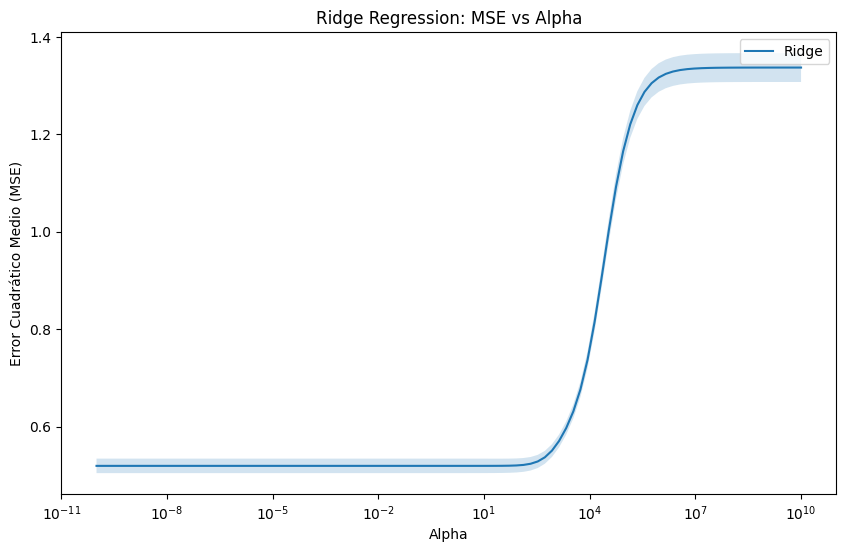

In [8]:
ridge = Ridge()
ridge_scores_mean, ridge_scores_std = evaluar_modelo(ridge, X_train_scaled, y_train, alphas)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, -ridge_scores_mean, label='Ridge')
plt.fill_between(alphas, -ridge_scores_mean + ridge_scores_std, -ridge_scores_mean - ridge_scores_std, alpha=0.2)
plt.xlabel('Alpha')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Ridge Regression: MSE vs Alpha')
plt.legend()
plt.show()


### Lasso Regression


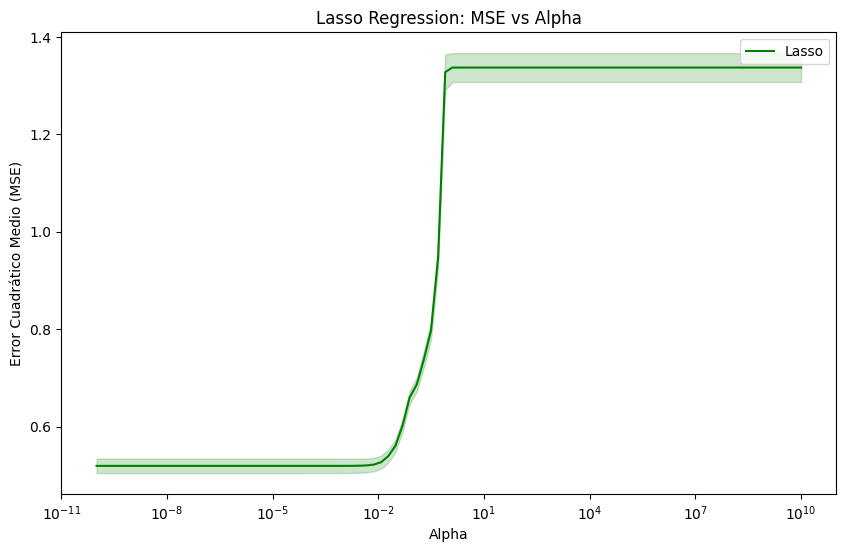

In [9]:
lasso = Lasso(max_iter=10000)
lasso_scores_mean, lasso_scores_std = evaluar_modelo(lasso, X_train_scaled, y_train, alphas)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, -lasso_scores_mean, label='Lasso', color='green')
plt.fill_between(alphas, -lasso_scores_mean + lasso_scores_std, -lasso_scores_mean - lasso_scores_std, color='green', alpha=0.2)
plt.xlabel('Alpha')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Lasso Regression: MSE vs Alpha')
plt.legend()
plt.show()


### Elastic Net Regression


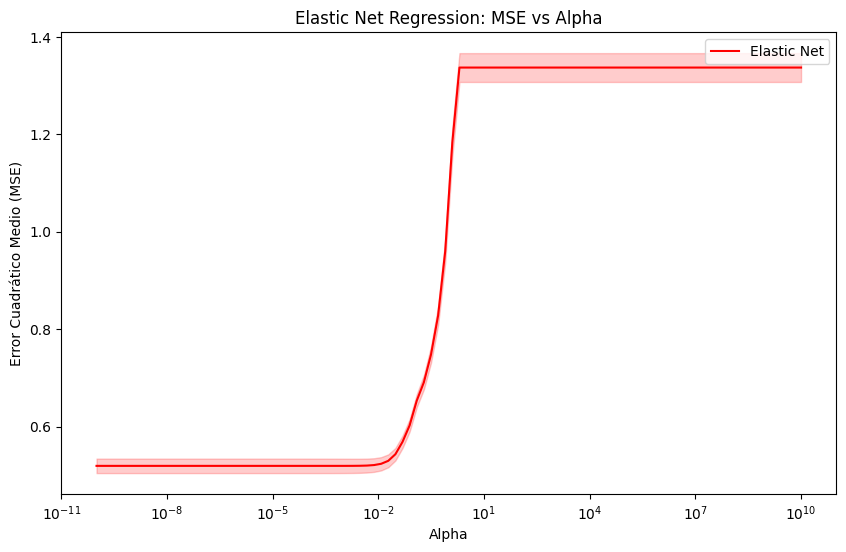

In [10]:
elasticnet = ElasticNet(max_iter=10000, l1_ratio=0.5)
elasticnet_scores_mean, elasticnet_scores_std = evaluar_modelo(elasticnet, X_train_scaled, y_train, alphas)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, -elasticnet_scores_mean, label='Elastic Net', color='red')
plt.fill_between(alphas, -elasticnet_scores_mean + elasticnet_scores_std, -elasticnet_scores_mean - elasticnet_scores_std, color='red', alpha=0.2)
plt.xlabel('Alpha')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Elastic Net Regression: MSE vs Alpha')
plt.legend()
plt.show()


## Comparación de los modelos


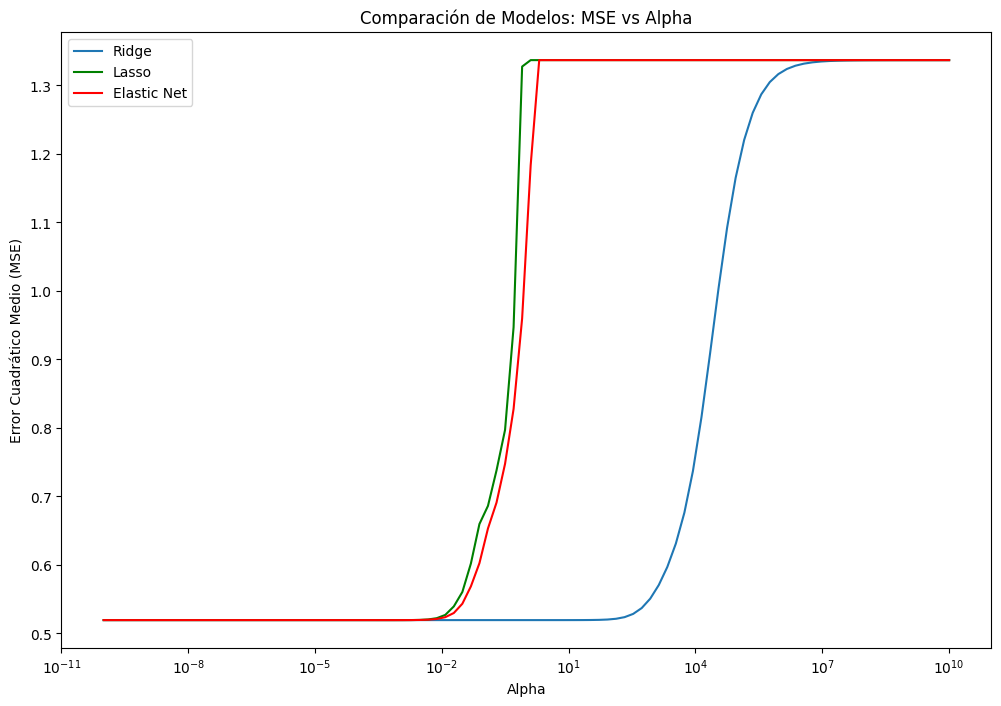

In [11]:
plt.figure(figsize=(12, 8))
plt.semilogx(alphas, -ridge_scores_mean, label='Ridge')
plt.semilogx(alphas, -lasso_scores_mean, label='Lasso', color='green')
plt.semilogx(alphas, -elasticnet_scores_mean, label='Elastic Net', color='red')
plt.xlabel('Alpha')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.title('Comparación de Modelos: MSE vs Alpha')
plt.legend()
plt.show()


## Determinar el mejor alpha usando GridSearchCV



### Ridge Regression


In [12]:
param_grid = {'alpha': alphas}
ridge = Ridge()
grid_search_ridge = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_ridge.fit(X_train_scaled, y_train)
print(f"Mejor alpha para Ridge: {grid_search_ridge.best_params_['alpha']}")
print(f"Mejor MSE (validación): {-grid_search_ridge.best_score_}")

Mejor alpha para Ridge: 0.12328467394420634
Mejor MSE (validación): 0.5192651994893178



### Lasso Regression


In [13]:
lasso = Lasso(max_iter=10000)
grid_search_lasso = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lasso.fit(X_train_scaled, y_train)
print(f"Mejor alpha para Lasso: {grid_search_lasso.best_params_['alpha']}")
print(f"Mejor MSE (validación): {-grid_search_lasso.best_score_}")

Mejor alpha para Lasso: 0.0007390722033525775
Mejor MSE (validación): 0.5192394033483667



### Elastic Net Regression


In [14]:
param_grid_elastic = {'alpha': alphas, 'l1_ratio': [0.1, 0.5, 0.9]}
elasticnet = ElasticNet(max_iter=10000)
grid_search_elastic = GridSearchCV(elasticnet, param_grid_elastic, cv=5, scoring='neg_mean_squared_error')
grid_search_elastic.fit(X_train_scaled, y_train)
print(f"Mejores parámetros para Elastic Net: {grid_search_elastic.best_params_}")
print(f"Mejor MSE (validación): {-grid_search_elastic.best_score_}")

Mejores parámetros para Elastic Net: {'alpha': 0.0007390722033525775, 'l1_ratio': 0.9}
Mejor MSE (validación): 0.5192420871997573



## Evaluar el rendimiento en el conjunto de prueba


In [15]:
# Mejor modelo Ridge
best_ridge = grid_search_ridge.best_estimator_
ridge_test_mse = mean_squared_error(y_test, best_ridge.predict(X_test_scaled))
print(f"MSE en prueba para Ridge: {ridge_test_mse}")

# Mejor modelo Lasso
best_lasso = grid_search_lasso.best_estimator_
lasso_test_mse = mean_squared_error(y_test, best_lasso.predict(X_test_scaled))
print(f"MSE en prueba para Lasso: {lasso_test_mse}")

# Mejor modelo Elastic Net
best_elastic = grid_search_elastic.best_estimator_
elastic_test_mse = mean_squared_error(y_test, best_elastic.predict(X_test_scaled))
print(f"MSE en prueba para Elastic Net: {elastic_test_mse}")

MSE en prueba para Ridge: 0.5558870562138446
MSE en prueba para Lasso: 0.5548429645844897
MSE en prueba para Elastic Net: 0.5549041864533681


In [16]:
best_lasso

Lasso(alpha=0.0007390722033525775, max_iter=10000)

In [17]:
# Obtener los coeficientes del mejor modelo
coef = best_lasso.coef_[0]  # Los coeficientes están en un array 2D, seleccionamos el primero

# Obtener los nombres de las características del conjunto de datos
feature_names = data.feature_names


# Crear un DataFrame para ordenar los coeficientes
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})

# Ordenar los coeficientes en orden descendente de valor absoluto
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

print(coef_df)  # Ver los coeficientes ordenados


      Feature  Coefficient
0      MedInc     0.850516
1    HouseAge     0.850516
2    AveRooms     0.850516
3   AveBedrms     0.850516
4  Population     0.850516
5    AveOccup     0.850516
6    Latitude     0.850516
7   Longitude     0.850516



## Importancia de determinar el alpha adecuado mediante validación cruzada

La elección del valor de alpha es crucial porque controla la cantidad de regularización aplicada al modelo:

- **Valores pequeños de alpha**: El modelo se ajusta más a los datos de entrenamiento, lo que puede llevar a un sobreajuste y mal rendimiento en datos nuevos.
- **Valores grandes de alpha**: El modelo se simplifica demasiado, lo que puede llevar a un subajuste y no capturar la complejidad del conjunto de datos.

La **validación cruzada** nos permite evaluar el rendimiento del modelo en diferentes particiones del conjunto de entrenamiento, proporcionando una estimación más fiable de cómo se comportará el modelo en datos no vistos. Esto nos ayuda a seleccionar el alpha que ofrece el mejor equilibrio entre sesgo y varianza.

## ¿Por qué se utilizan métricas negativas?

En bibliotecas como scikit-learn, las funciones de evaluación están diseñadas para que un **valor más alto indique un mejor rendimiento**. Sin embargo, para métricas donde un valor más bajo es mejor (como el **Error Cuadrático Medio - MSE**), se utiliza su negativo al calcular los puntajes.

Por ejemplo:

- **MSE positivo**: Valores más bajos son mejores.
- **MSE negativo**: Al multiplicar por -1, valores más altos (menos negativos) son mejores.

Esto permite que las funciones de optimización y evaluación mantengan una convención consistente, facilitando la comparación y selección de modelos.




## Análisis de los coeficientes respecto a los valores de alpha

En esta sección, exploraremos cómo los coeficientes de los modelos **Ridge**, **Lasso** y **Elastic Net** cambian a medida que variamos el valor de alpha. Esto es importante para entender cómo la regularización afecta la complejidad del modelo y la importancia de las variables.



### Función para obtener coeficientes

Crearemos una función que ajuste el modelo para diferentes valores de alpha y registre los coeficientes correspondientes.


In [18]:
def obtener_coeficientes(modelo, X, y, alphas):
    """
    Ajusta un modelo de regresión para diferentes valores de alpha y registra los coeficientes.

    Parámetros:
    - modelo: instancia del modelo (Ridge, Lasso, ElasticNet)
    - X: matriz de características
    - y: vector objetivo
    - alphas: lista de valores de alpha a evaluar

    Retorna:
    - coeficientes: matriz donde cada fila corresponde a los coeficientes para un alpha
    """
    coeficientes = []

    for alpha in alphas:
        # Establecer el valor de alpha en el modelo
        modelo.set_params(alpha=alpha)

        # Ajustar el modelo con los datos completos de entrenamiento
        modelo.fit(X, y)

        # Registrar los coeficientes
        coeficientes.append(modelo.coef_)

    return np.array(coeficientes)


```python

```



### 11.2. Obtener y graficar coeficientes para Ridge Regression


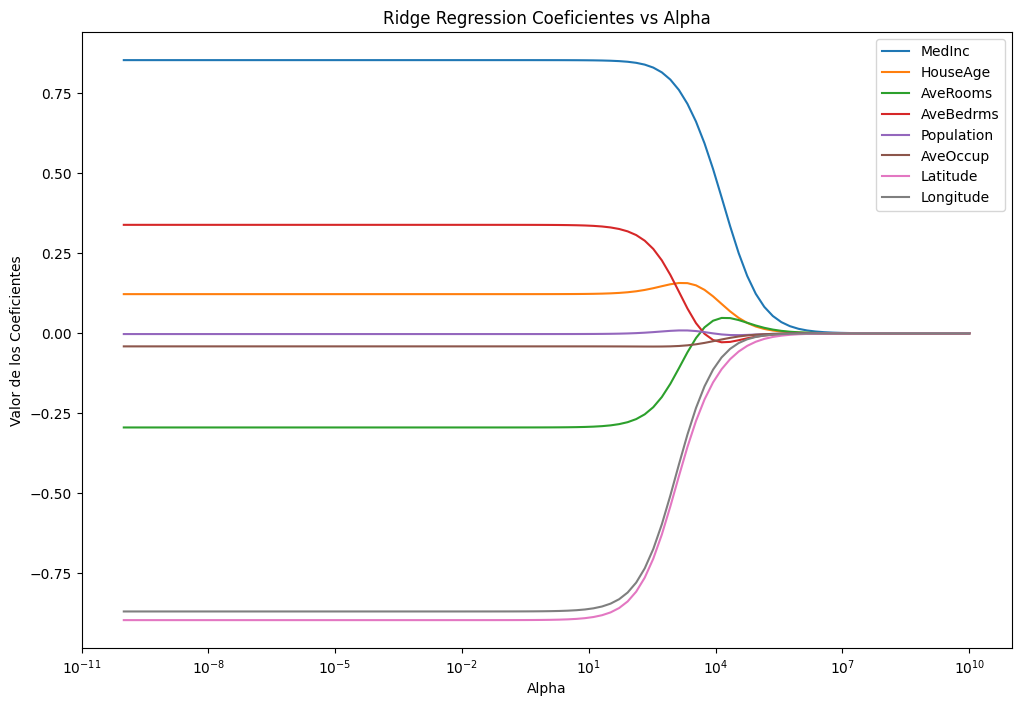

In [19]:
# Crear una instancia del modelo Ridge
ridge = Ridge()

# Obtener los coeficientes para diferentes alphas
ridge_coefs = obtener_coeficientes(ridge, X_train_scaled, y_train, alphas)

# Graficar los coeficientes en función de alpha
plt.figure(figsize=(12, 8))

# Iterar sobre cada coeficiente
for i in range(ridge_coefs.shape[1]):
    plt.semilogx(alphas, ridge_coefs[:, i], label=X.columns[i])

plt.xlabel('Alpha')
plt.ylabel('Valor de los Coeficientes')
plt.title('Ridge Regression Coeficientes vs Alpha')
plt.legend(loc='best')
plt.show()


**Explicación:**

- Observamos cómo los coeficientes de **Ridge Regression** cambian suavemente a medida que aumenta alpha.
- Los coeficientes tienden a disminuir en magnitud con alphas más grandes debido a la penalización L2.
- Ningún coeficiente se reduce exactamente a cero; en cambio, se acercan a cero gradualmente.



### 11.3. Obtener y graficar coeficientes para Lasso Regression


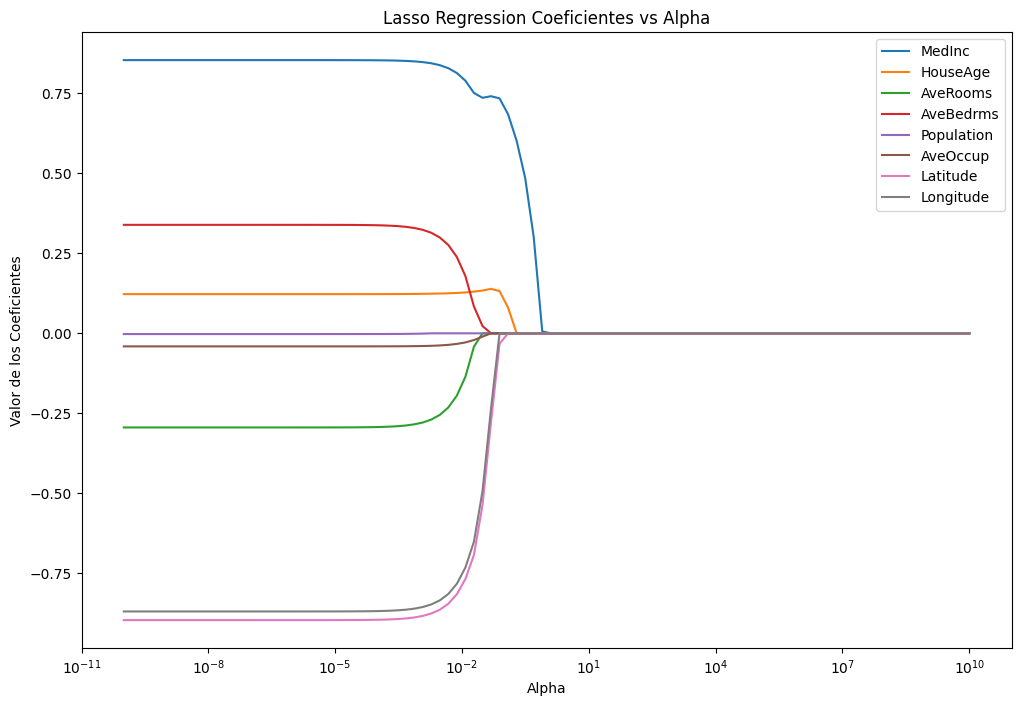

In [20]:
# Crear una instancia del modelo Lasso
lasso = Lasso(max_iter=10000)

# Obtener los coeficientes para diferentes alphas
lasso_coefs = obtener_coeficientes(lasso, X_train_scaled, y_train, alphas)

# Graficar los coeficientes en función de alpha
plt.figure(figsize=(12, 8))

# Iterar sobre cada coeficiente
for i in range(lasso_coefs.shape[1]):
    plt.semilogx(alphas, lasso_coefs[:, i], label=X.columns[i])

plt.xlabel('Alpha')
plt.ylabel('Valor de los Coeficientes')
plt.title('Lasso Regression Coeficientes vs Alpha')
plt.legend(loc='best')
plt.show()


**Explicación:**

- En **Lasso Regression**, los coeficientes pueden reducirse exactamente a cero para valores de alpha suficientemente grandes.
- Esto resulta en un modelo más **esparso**, seleccionando automáticamente características relevantes.
- Podemos observar que algunas características se eliminan del modelo (coeficiente cero) cuando alpha aumenta.

### 11.4. Obtener y graficar coeficientes para Elastic Net Regression


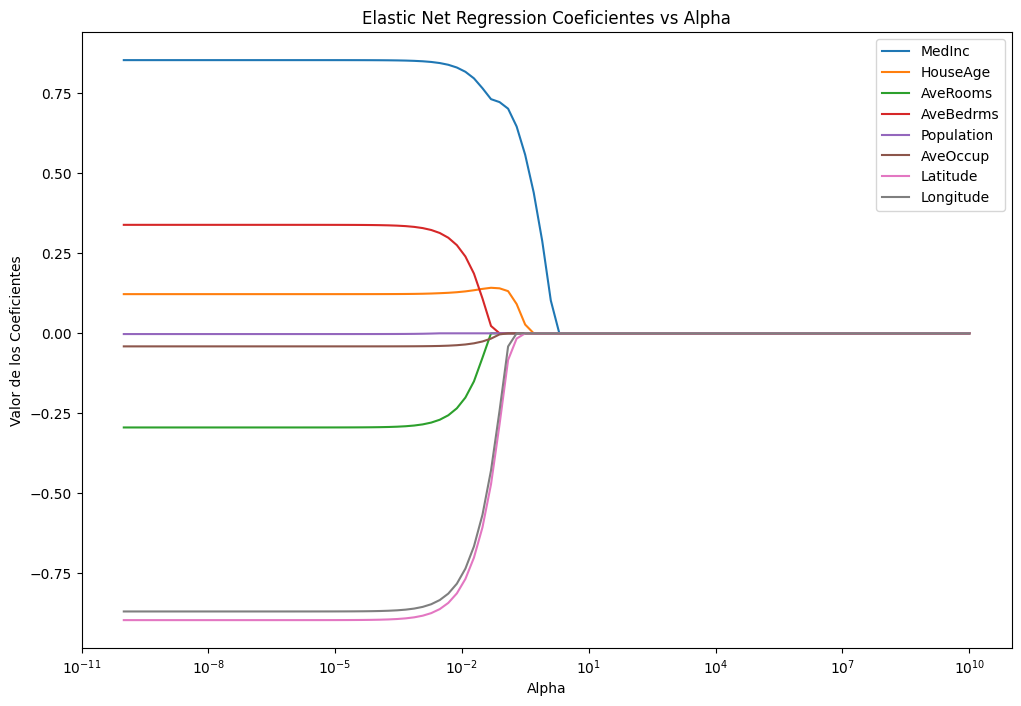

In [21]:
# Crear una instancia del modelo Elastic Net con l1_ratio=0.5
elasticnet = ElasticNet(max_iter=10000, l1_ratio=0.5)

# Obtener los coeficientes para diferentes alphas
elasticnet_coefs = obtener_coeficientes(elasticnet, X_train_scaled, y_train, alphas)

# Graficar los coeficientes en función de alpha
plt.figure(figsize=(12, 8))

# Iterar sobre cada coeficiente
for i in range(elasticnet_coefs.shape[1]):
    plt.semilogx(alphas, elasticnet_coefs[:, i], label=X.columns[i])

plt.xlabel('Alpha')
plt.ylabel('Valor de los Coeficientes')
plt.title('Elastic Net Regression Coeficientes vs Alpha')
plt.legend(loc='best')
plt.show()


**Explicación:**

- **Elastic Net** combina las penalizaciones L1 y L2, por lo que observamos comportamientos intermedios entre Ridge y Lasso.
- Los coeficientes pueden reducirse a cero como en Lasso, pero también muestran un decrecimiento gradual como en Ridge.
- Esto permite una regularización más flexible y puede ser útil cuando hay correlación entre variables predictoras.

### 11.5. Comparación y análisis de los coeficientes

**Observaciones Generales:**

- **Ridge Regression:**
  - Aplica una penalización L2 que reduce todos los coeficientes de forma continua.
  - Útil cuando tenemos muchas variables correlacionadas.
  - No elimina variables (coeficientes no se vuelven exactamente cero).

- **Lasso Regression:**
  - Utiliza una penalización L1 que puede reducir algunos coeficientes exactamente a cero.
  - Realiza selección de características incorporada.
  - Puede ser útil para obtener modelos más simples y esparsos.

- **Elastic Net Regression:**
  - Combina las penalizaciones L1 y L2.
  - Puede manejar situaciones donde hay múltiples variables correlacionadas y realizar selección de características.
  - Proporciona un balance entre la reducción de coeficientes y la eliminación de variables.

**Importancia de Visualizar los Coeficientes:**

- Visualizar cómo cambian los coeficientes con alpha nos ayuda a entender el impacto de la regularización.
- Podemos identificar qué variables son más importantes y cómo su influencia en el modelo cambia con diferentes niveles de regularización.
- Esto es especialmente útil en contextos donde la interpretabilidad del modelo es crucial.

